<br>
<br>
<center><h1>Crocodiles Species Around the World</h1></center>
<br>
<br>
<center><img src="https://upload.wikimedia.org/wikipedia/commons/2/29/Pangil_Crocodile_Park_Davao_City.jpg"></img></center>

# Introduction

This is a notebook for analysis of Global Crocodile Species dataset.

If you do not like to browse through the data analysis part, you can go directly to the visualisations.

Enjoy and let me know your feedback about this work and if you would like to see more such analyses.


# Data analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path
from datetime import datetime

In [2]:
df = pd.read_csv("/kaggle/input/global-crocodile-species-dataset/crocodile_dataset.csv")

## Glimpse the data

In [3]:
df.head()

,Observation ID,Common Name,Scientific Name,Family,Genus,Observed Length (m),Observed Weight (kg),Age Class,Sex,Date of Observation,Country/Region,Habitat Type,Conservation Status,Observer Name,Notes
0,1,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,1.90,62.0,Adult,Male,31-03-2018,Belize,Swamps,Least Concern,Allison Hill,Cause bill scientist nation opportunity.
1,2,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.09,334.5,Adult,Male,28-01-2015,Venezuela,Mangroves,Vulnerable,Brandon Hall,Ago current practice nation determine operatio...
2,3,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,1.08,118.2,Juvenile,Unknown,07-12-2010,Venezuela,Flooded Savannas,Critically Endangered,Melissa Peterson,Democratic shake bill here grow gas enough ana...
3,4,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,2.42,90.4,Adult,Male,01-11-2019,Mexico,Rivers,Least Concern,Edward Fuller,Officer relate animal direction eye bag do.
4,5,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,3.75,269.4,Adult,Unknown,15-07-2019,India,Rivers,Vulnerable,Donald Reid,Class great prove reduce raise author play mov...


In [4]:
df.shape

(1000, 15)

In [5]:
df.columns

Index(['Observation ID', 'Common Name', 'Scientific Name', 'Family', 'Genus',
       'Observed Length (m)', 'Observed Weight (kg)', 'Age Class', 'Sex',
       'Date of Observation', 'Country/Region', 'Habitat Type',
       'Conservation Status', 'Observer Name', 'Notes'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Observation ID        1000 non-null   int64  
 1   Common Name           1000 non-null   object 
 2   Scientific Name       1000 non-null   object 
 3   Family                1000 non-null   object 
 4   Genus                 1000 non-null   object 
 5   Observed Length (m)   1000 non-null   float64
 6   Observed Weight (kg)  1000 non-null   float64
 7   Age Class             1000 non-null   object 
 8   Sex                   1000 non-null   object 
 9   Date of Observation   1000 non-null   object 
 10  Country/Region        1000 non-null   object 
 11  Habitat Type          1000 non-null   object 
 12  Conservation Status   1000 non-null   object 
 13  Observer Name         1000 non-null   object 
 14  Notes                 1000 non-null   object 
dtypes: float64(2), int64(1

In [7]:
df.describe()

,Observation ID,Observed Length (m),Observed Weight (kg)
count,1000.000000,1000.000000,1000.000000
mean,500.500000,2.415110,155.771900
std,288.819436,1.097542,175.186788
min,1.000000,0.140000,4.400000
25%,250.750000,1.637500,53.225000
50%,500.500000,2.430000,100.600000
75%,750.250000,3.010000,168.875000
max,1000.000000,6.120000,1139.700000


In [8]:
df["Genus"].value_counts()

Genus
Crocodylus     784
Mecistops      111
Osteolaemus    105
Name: count, dtype: int64

In [9]:
df["Family"].value_counts()

Family
Crocodylidae    1000
Name: count, dtype: int64

In [10]:
df["Scientific Name"].value_counts()

Scientific Name
Crocodylus novaeguineae    68
Crocodylus raninus         67
Crocodylus acutus          66
Crocodylus moreletii       64
Crocodylus rhombifer       59
Crocodylus porosus         58
Crocodylus mindorensis     58
Crocodylus intermedius     58
Osteolaemus tetraspis      57
Mecistops leptorhynchus    56
Mecistops cataphractus     55
Crocodylus suchus          52
Crocodylus halli           49
Osteolaemus osborni        48
Crocodylus niloticus       48
Crocodylus palustris       47
Crocodylus siamensis       45
Crocodylus johnstoni       45
Name: count, dtype: int64

In [11]:
df["Common Name"].value_counts()

Common Name
New Guinea Crocodile                         68
Borneo Crocodile (disputed)                  67
American Crocodile                           66
Morelet's Crocodile                          64
Cuban Crocodile                              59
Saltwater Crocodile                          58
Philippine Crocodile                         58
Orinoco Crocodile                            58
West African Dwarf Crocodile                 57
Central African Slender-snouted Crocodile    56
West African Slender-snouted Crocodile       55
West African Crocodile                       52
Hall's New Guinea Crocodile                  49
Congo Dwarf Crocodile                        48
Nile Crocodile                               48
Mugger Crocodile (Marsh Crocodile)           47
Siamese Crocodile                            45
Freshwater Crocodile (Johnstone's)           45
Name: count, dtype: int64

## Where are leaving each species?

In [12]:
gr = df.groupby(["Common Name", "Scientific Name", "Family", "Genus"])["Country/Region"].apply(set).reset_index()
gr["Country/Region"] = gr["Country/Region"].apply(lambda x: list(x))
gr

,Common Name,Scientific Name,Family,Genus,Country/Region
0,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,"[Mexico, Colombia, Costa Rica, USA (Florida), ..."
1,Borneo Crocodile (disputed),Crocodylus raninus,Crocodylidae,Crocodylus,"[Malaysia (Borneo), Indonesia (Borneo)]"
2,Central African Slender-snouted Crocodile,Mecistops leptorhynchus,Crocodylidae,Mecistops,"[Congo Basin Countries, Gabon, Cameroon]"
3,Congo Dwarf Crocodile,Osteolaemus osborni,Crocodylidae,Osteolaemus,"[Central African Republic, Congo (DRC)]"
4,Cuban Crocodile,Crocodylus rhombifer,Crocodylidae,Crocodylus,[Cuba]
5,Freshwater Crocodile (Johnstone's),Crocodylus johnstoni,Crocodylidae,Crocodylus,[Australia]
6,Hall's New Guinea Crocodile,Crocodylus halli,Crocodylidae,Crocodylus,[Papua New Guinea]
7,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,"[Mexico, Belize, Guatemala]"
8,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,"[Pakistan, Sri Lanka, Iran (historic), India, ..."
9,New Guinea Crocodile,Crocodylus novaeguineae,Crocodylidae,Crocodylus,"[Indonesia (Papua), Papua New Guinea]"


## What are the species with the largest observed weight?

In [13]:
gr = df.groupby(["Common Name", "Scientific Name", "Family", "Genus"])["Observed Weight (kg)"].max().reset_index()
gr = gr.sort_values(by="Observed Weight (kg)", ascending=False).head(10)
gr[["Common Name", "Scientific Name", "Family", "Genus", "Observed Weight (kg)"]]

,Common Name,Scientific Name,Family,Genus,Observed Weight (kg)
13,Saltwater Crocodile,Crocodylus porosus,Crocodylidae,Crocodylus,1139.7
10,Nile Crocodile,Crocodylus niloticus,Crocodylidae,Crocodylus,998.3
11,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,718.2
0,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,418.1
8,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,292.8
1,Borneo Crocodile (disputed),Crocodylus raninus,Crocodylidae,Crocodylus,273.7
17,West African Slender-snouted Crocodile,Mecistops cataphractus,Crocodylidae,Mecistops,230.9
4,Cuban Crocodile,Crocodylus rhombifer,Crocodylidae,Crocodylus,203.8
15,West African Crocodile,Crocodylus suchus,Crocodylidae,Crocodylus,201.2
6,Hall's New Guinea Crocodile,Crocodylus halli,Crocodylidae,Crocodylus,198.2


## What are the species with longest body?

In [14]:
gr = df.groupby(["Common Name", "Scientific Name", "Family", "Genus"])["Observed Length (m)"].max().reset_index()
gr = gr.sort_values(by="Observed Length (m)", ascending=False).head(10)
gr[["Common Name", "Scientific Name", "Family", "Genus", "Observed Length (m)"]]

,Common Name,Scientific Name,Family,Genus,Observed Length (m)
13,Saltwater Crocodile,Crocodylus porosus,Crocodylidae,Crocodylus,6.12
10,Nile Crocodile,Crocodylus niloticus,Crocodylidae,Crocodylus,5.31
11,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,4.81
0,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.33
8,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,4.03
1,Borneo Crocodile (disputed),Crocodylus raninus,Crocodylidae,Crocodylus,3.91
6,Hall's New Guinea Crocodile,Crocodylus halli,Crocodylidae,Crocodylus,3.49
17,West African Slender-snouted Crocodile,Mecistops cataphractus,Crocodylidae,Mecistops,3.41
7,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,3.40
4,Cuban Crocodile,Crocodylus rhombifer,Crocodylidae,Crocodylus,3.38


# Data visualization

In [15]:
df['Date of Observation'] = pd.to_datetime(df['Date of Observation'], dayfirst=True, errors='coerce')
df['Year'] = df['Date of Observation'].dt.year

## Crocodile length vs. weight by species

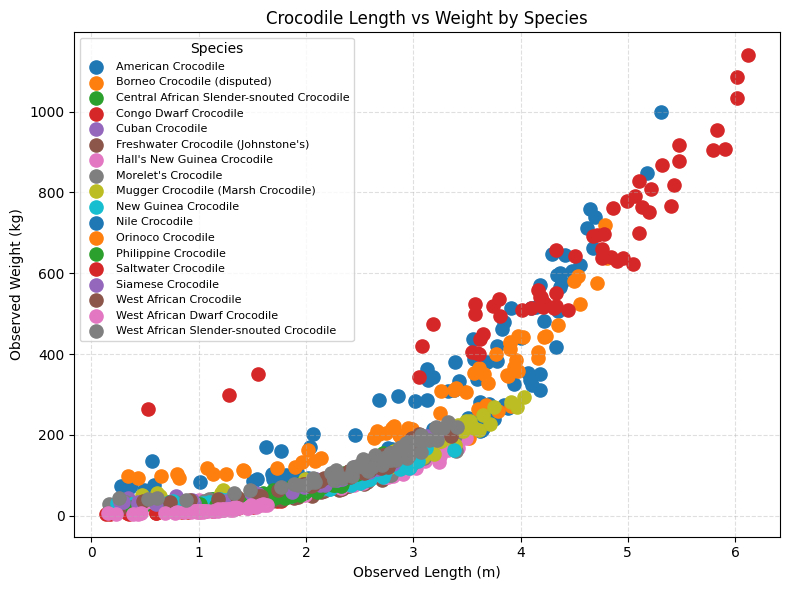

In [16]:
plt.figure(figsize=(8, 6))
for species, sub in df.groupby('Common Name'):
    plt.scatter(sub['Observed Length (m)'], sub['Observed Weight (kg)'], label=species, s=90)
plt.xlabel('Observed Length (m)')
plt.ylabel('Observed Weight (kg)')
plt.title("Crocodile Length vs Weight by Species")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Species', fontsize=8)
plt.tight_layout()
plt.show()

## Crocodile length vs. weight by Genus

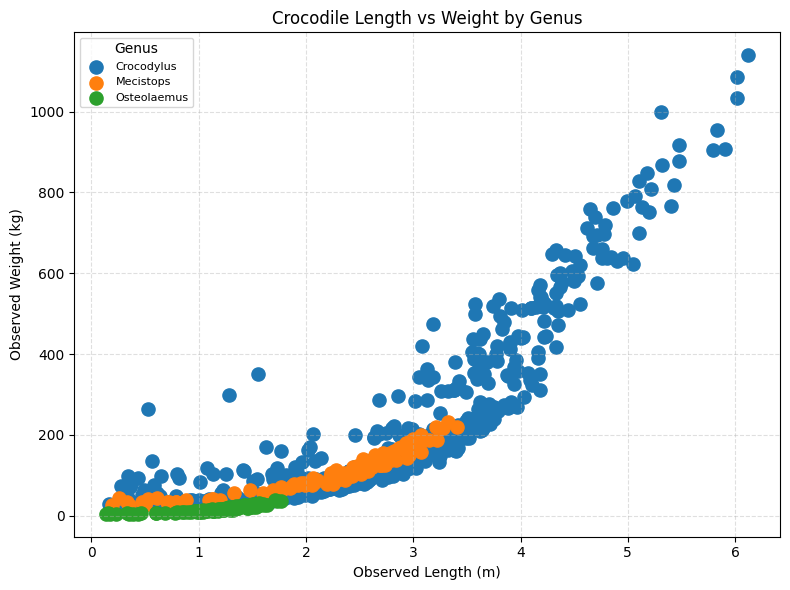

In [17]:
plt.figure(figsize=(8, 6))
for genus, sub in df.groupby('Genus'):
    plt.scatter(sub['Observed Length (m)'], sub['Observed Weight (kg)'], label=genus, s=90)
plt.xlabel('Observed Length (m)')
plt.ylabel('Observed Weight (kg)')
plt.title("Crocodile Length vs Weight by Genus")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Genus', fontsize=8)
plt.tight_layout()
plt.show()

## Crocodile length vs. weight by Habitat Type 

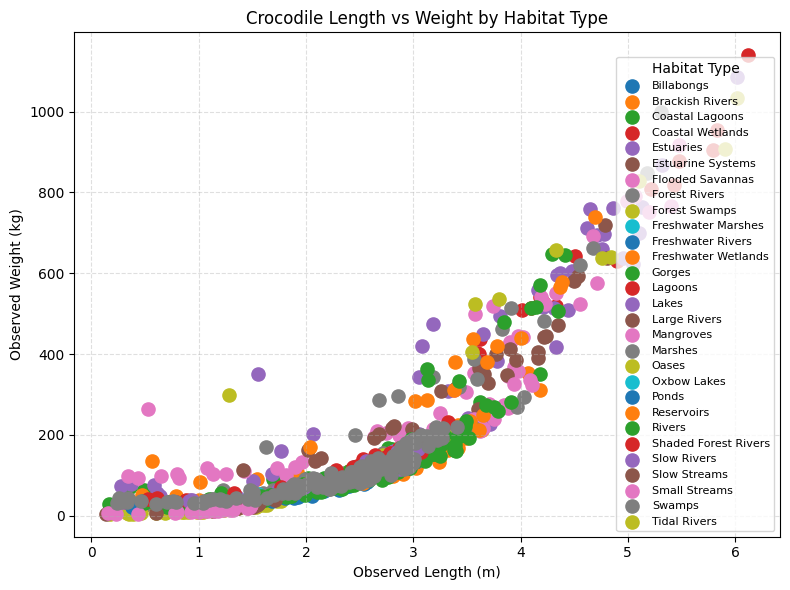

In [18]:
plt.figure(figsize=(8, 6))
for habitat, sub in df.groupby('Habitat Type'):
    plt.scatter(sub['Observed Length (m)'], sub['Observed Weight (kg)'], label=habitat, s=90)
plt.xlabel('Observed Length (m)')
plt.ylabel('Observed Weight (kg)')
plt.title("Crocodile Length vs Weight by Habitat Type")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Habitat Type', fontsize=8)
plt.tight_layout()
plt.show()

# Crocodile lengts vs. weight by Conservation Status

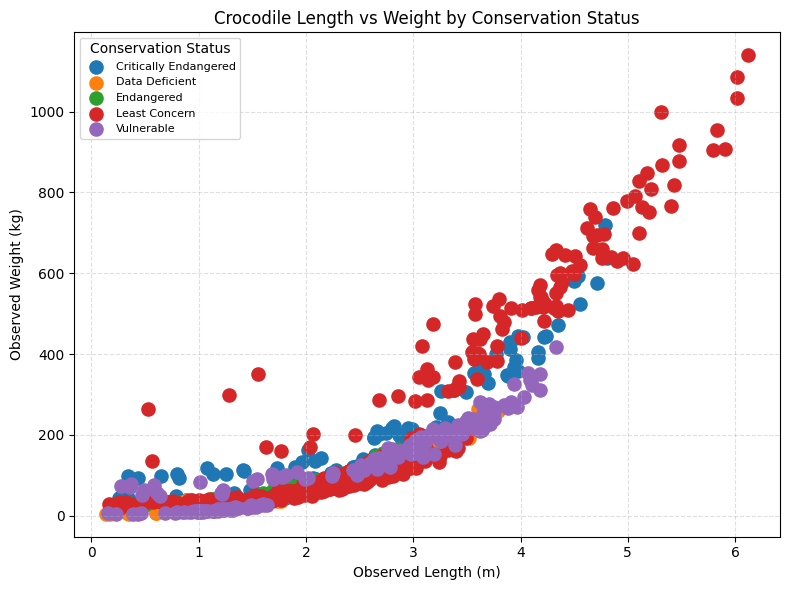

In [19]:
plt.figure(figsize=(8, 6))
for cons_stat, sub in df.groupby('Conservation Status'):
    plt.scatter(sub['Observed Length (m)'], sub['Observed Weight (kg)'], label=cons_stat, s=90)
plt.xlabel('Observed Length (m)')
plt.ylabel('Observed Weight (kg)')
plt.title("Crocodile Length vs Weight by Conservation Status")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Conservation Status', fontsize=8)
plt.tight_layout()
plt.show()

## Observations by Conservation Status (bar)

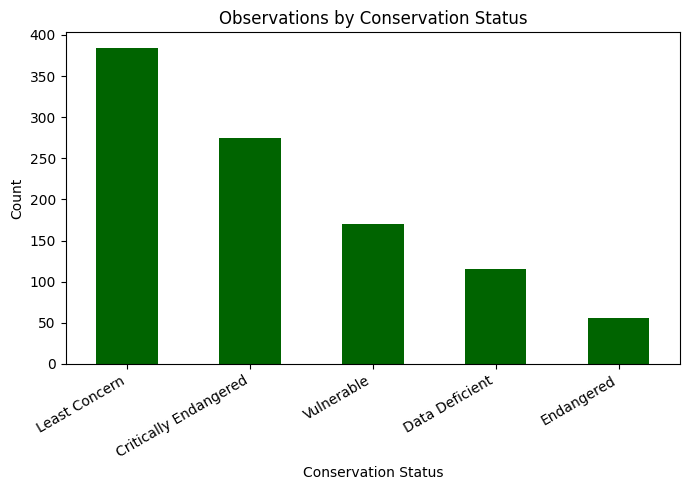

In [20]:
plt.figure(figsize=(7, 5))
status_counts = df['Conservation Status'].value_counts()
status_counts.plot(kind='bar', color="darkgreen")
plt.title('Observations by Conservation Status')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Habitat distribution (bar)

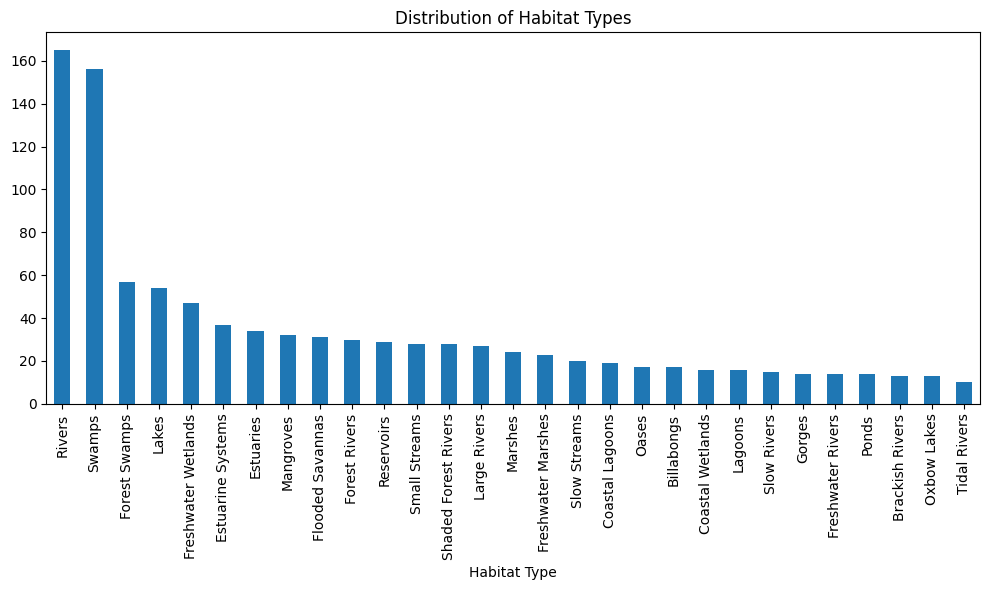

In [21]:
plt.figure(figsize=(10, 6))
hab_counts = df['Habitat Type'].value_counts()
hab_counts.plot(kind='bar')
plt.title('Distribution of Habitat Types')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Timeline of observations (area/line by year)

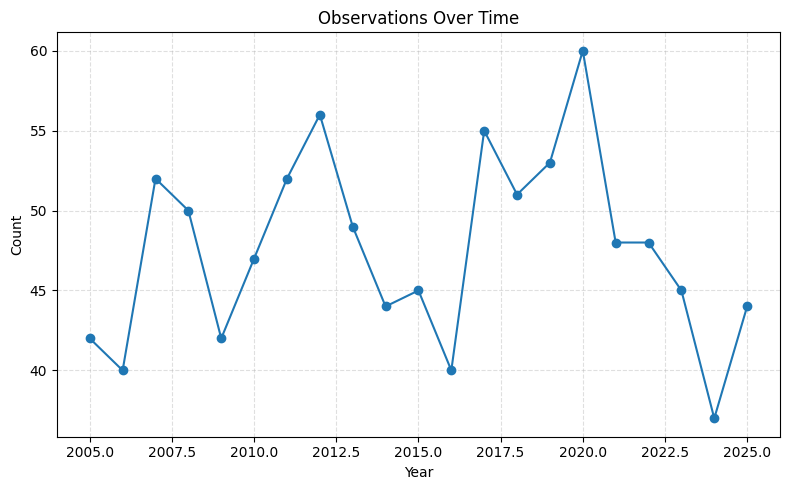

In [22]:
plt.figure(figsize=(8, 5))
year_counts = df.groupby('Year').size().sort_index()
year_counts.plot(kind='line', marker='o')
plt.title('Observations Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Timeline of observations (area/line by year) - grouped by Genus

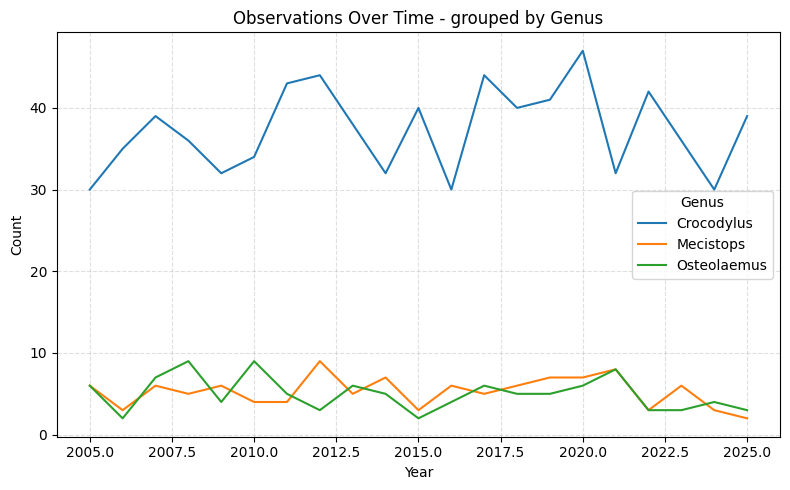

In [23]:
plt.figure(figsize=(8, 5))
gr = df.groupby(["Year", 'Genus'])["Observation ID"].count().reset_index()
gr.columns = ["Year", "Genus", "Count"]
for genus, sub in gr.groupby('Genus'):
    plt.plot(sub['Year'], sub['Count'], label=genus)
plt.title('Observations Over Time - grouped by Genus')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title="Genus")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Timeline of observations (area/line by year) - grouped by Conservation Status

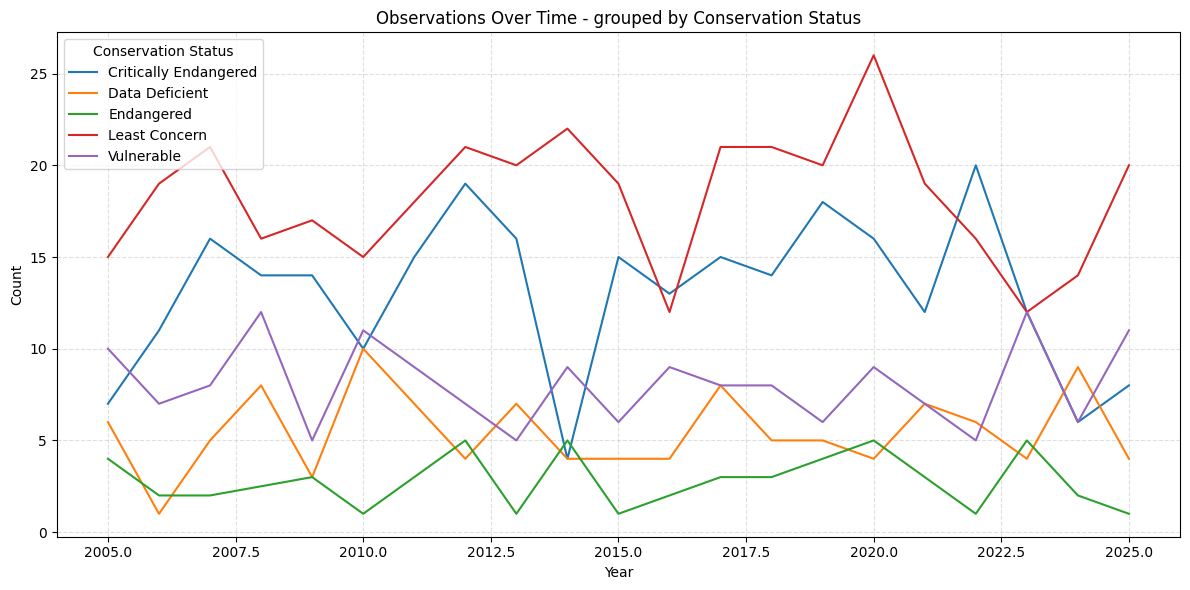

In [24]:
plt.figure(figsize=(12, 6))
gr = df.groupby(["Year", 'Conservation Status'])["Observation ID"].count().reset_index()
gr.columns = ["Year", "Conservation Status", "Count"]
for genus, sub in gr.groupby('Conservation Status'):
    plt.plot(sub['Year'], sub['Count'], label=genus)
plt.title('Observations Over Time - grouped by Conservation Status')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title="Conservation Status")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Boxplot: Length by Species

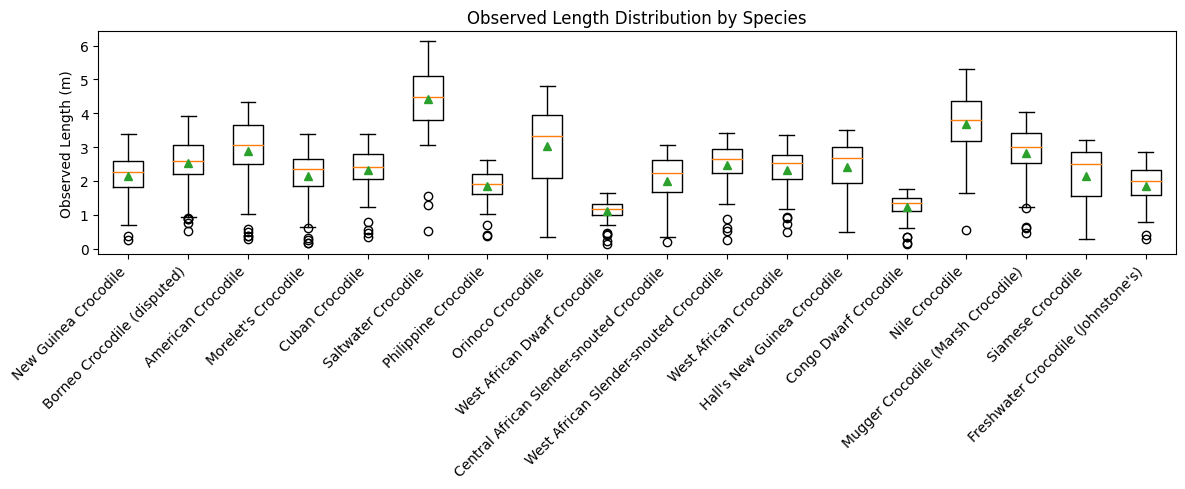

In [25]:
plt.figure(figsize=(12, 5))
species_order = df['Common Name'].value_counts().index.tolist()
data_by_species = [df[df['Common Name']==sp]['Observed Length (m)'] for sp in species_order]
plt.boxplot(data_by_species, labels=species_order, showmeans=True)
plt.title('Observed Length Distribution by Species')
plt.ylabel('Observed Length (m)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Boxplot: Length by Genus

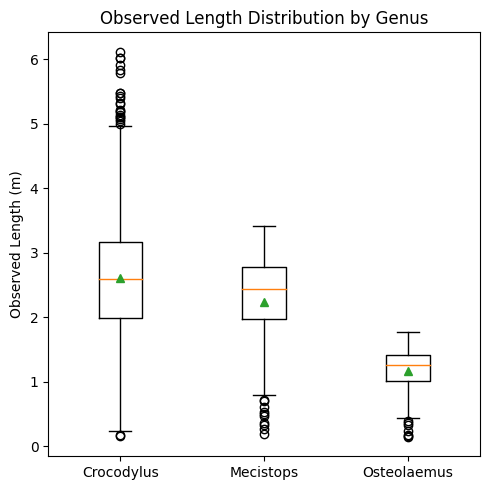

In [26]:
plt.figure(figsize=(5, 5))
species_order = df['Genus'].value_counts().index.tolist()
data_by_species = [df[df['Genus']==sp]['Observed Length (m)'] for sp in species_order]
plt.boxplot(data_by_species, labels=species_order, showmeans=True)
plt.title('Observed Length Distribution by Genus')
plt.ylabel('Observed Length (m)')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

## Boxplot: Weight by species

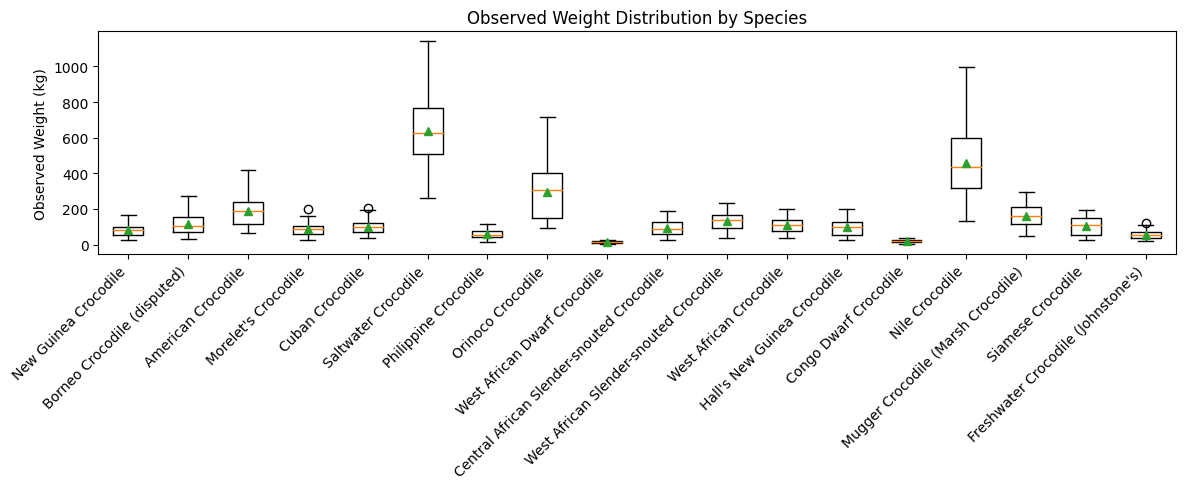

In [27]:
plt.figure(figsize=(12, 5))
species_order = df['Common Name'].value_counts().index.tolist()
data_by_species = [df[df['Common Name']==sp]['Observed Weight (kg)'] for sp in species_order]
plt.boxplot(data_by_species, labels=species_order, showmeans=True)
plt.title('Observed Weight Distribution by Species')
plt.ylabel('Observed Weight (kg)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Boxplot: Weight by Genus

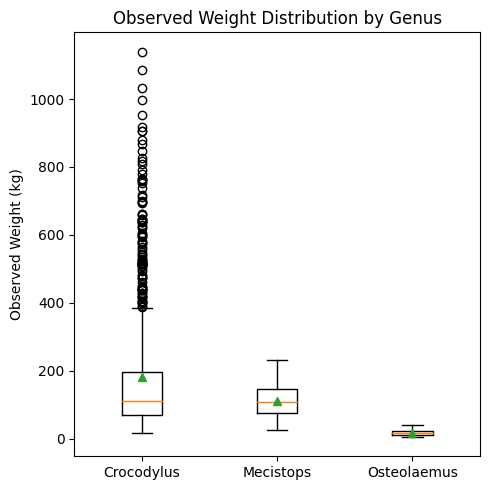

In [28]:
plt.figure(figsize=(5, 5))
species_order = df['Genus'].value_counts().index.tolist()
data_by_species = [df[df['Genus']==sp]['Observed Weight (kg)'] for sp in species_order]
plt.boxplot(data_by_species, labels=species_order, showmeans=True)
plt.title('Observed Weight Distribution by Genus')
plt.ylabel('Observed Weight (kg)')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()